In [1]:
!pip install openai

In [2]:
from google.colab import userdata
from openai import OpenAI

client = OpenAI(
    api_key=userdata.get('OPENAI_API_KEY'),
    base_url="https://openrouter.ai/api/v1"
)

In [3]:
def gerar_embedding(texto):
    response = client.embeddings.create(
        model="nvidia/nemotron-3-embed-1b:free",
        input=texto,
        encoding_format="float"
    )
    return response.data[0].embedding, response.usage

In [4]:
embedding, uso = gerar_embedding("The quick brown fox jumps over the lazy dog")

print(f"Tamanho do vetor: {len(embedding)}")
print(f"Tokens gastos: {uso.total_tokens}")
print(f"\nPrimeiros 10 valores do vetor:")
print(embedding[:10])

Tamanho do vetor: 2048
Tokens gastos: 11

Primeiros 10 valores do vetor:
[0.09515459, -0.0010948398, -0.006354056, -0.029411761, -0.021192072, 0.040806904, -0.020835515, 0.033925354, -0.0038780821, -0.011751701]


In [5]:
!pip install scikit-learn matplotlib

In [7]:
palavras = ["gato", "felino", "cachorro", "carro", "caminhão", "moto", "banana", "maçã", "goiaba"]

embeddings_lista = []
for palavra in palavras:
    emb, _ = gerar_embedding(palavra)
    embeddings_lista.append(emb)
    print(f"✅ Embedding gerado para: {palavra}")

✅ Embedding gerado para: gato
✅ Embedding gerado para: felino
✅ Embedding gerado para: cachorro
✅ Embedding gerado para: carro
✅ Embedding gerado para: caminhão
✅ Embedding gerado para: moto
✅ Embedding gerado para: banana
✅ Embedding gerado para: maçã
✅ Embedding gerado para: goiaba


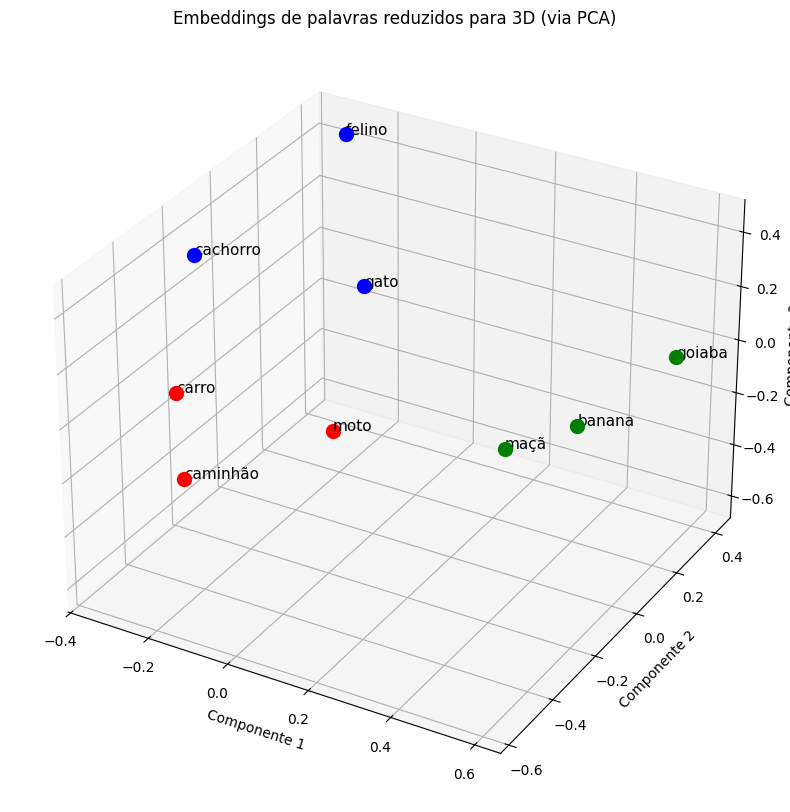

In [10]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=3)
coords_3d = pca.fit_transform(np.array(embeddings_lista))

cores = ['blue', 'blue', 'blue', 'red', 'red', 'red', 'green', 'green', 'green']

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

for i, palavra in enumerate(palavras):
    x, y, z = coords_3d[i]
    ax.scatter(x, y, z, c=cores[i], s=100)
    ax.text(x, y, z, palavra, fontsize=11)

ax.set_title("Embeddings de palavras reduzidos para 3D (via PCA)")
ax.set_xlabel("Componente 1")
ax.set_ylabel("Componente 2")
ax.set_zlabel("Componente 3")
plt.show()